# Stochastic Gradient Descent (SGD)

Your task is to solve a 1-dimensional linear-regression task.
Here we assume the model class to be linear functions
$$
\mathcal{F} = \{ f(x; w) : f(x; w) = w^\top x, w \in \mathbb{R} \}.
$$
In traditional ML we know that we can easily find the closed-form solution for this, but let's focus on iterative methods---stochastic gradient descent (SGD).
Here we will play with different learning rates $\alpha$ to see how it impacts the speed of convergence (if it converges).
We will also briefly investigate SGD with momentum $\mu$.

Your task is to:
1. Implement the squared loss $\ell(x, y; w) = \frac{1}{2}(w^\top x - y)^2$ and its gradient w.r.t. parameters $w$.
1. Implement SGD: $w_{t + 1} = w_t - \alpha \nabla_w \ell(x, y; w_t)$
1. Implement SGD with momentum: $v_{t + 1} = \mu v_t - \alpha \nabla_w \ell(x, y; w_t), \text{\quad} w_{t + 1} = w_t + v_{t + 1}$
1. Try to find good hyperparameters such that the learned model has low errors

### Credits
Bryan Chan, Nov. 2024  
References from CSCC11 tutorial on linear regression

In [10]:
# Import packages
import matplotlib.pyplot as plt
import numpy as np

from pprint import pprint

[(0.0, 4.764052345967664),
 (1.0, 5.400157208367223),
 (2.0, 7.978737984105739),
 (3.0, 11.240893199201459),
 (4.0, 12.867557990149967),
 (5.0, 12.02272212012359),
 (6.0, 15.95008841752559),
 (7.0, 16.848642791702304),
 (8.0, 18.896781148206443),
 (9.0, 21.410598501938374)]


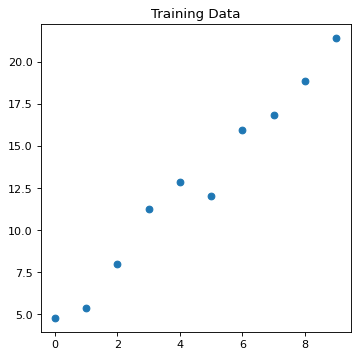

In [11]:
# Set seed for reproducibility.
seed = 0
np.random.seed(0)

# Let's generate some training data and visual it
true_w = np.array([3, 2])
noise_mean = 0
noise_variance = 1

# Generate training data
train_X = np.expand_dims(np.arange(10), axis=1)

# First dimension is for the bias term
train_X = np.hstack((np.ones((train_X.shape[0], 1)), train_X))

noise = np.random.normal(loc=noise_mean, scale=noise_variance, size=len(train_X))
train_y = train_X @ true_w + noise

# Visualize the dataset
pprint([(input.item(), output.item()) for input, output in zip(train_X[:, -1], train_y)])


fig1 = plt.figure(num=None, figsize=(5, 5), dpi=80, facecolor='w', edgecolor='k')
plt.title("Training Data")
plt.scatter(train_X[:, -1], train_y)
plt.show()

In [12]:
def visualize_2d(x, observed_y, trained_w, true_w, step_infos):
    """ This visualize the 2D curves """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=80, facecolor='w', edgecolor='k')
    axes[0].scatter(x[:, -1], observed_y)
    
    axes[0].plot(x[:, -1], x @ trained_w, label="Trained Parameters")
    axes[0].plot(x[:, -1], x @ true_w, label="Ground Truth Parameters")
    axes[0].set_title("Predictions")

    axes[0].legend()

    axes[1].plot(np.arange(len(step_infos["loss"])), step_infos["loss"])
    axes[1].set_title("Training Loss")

    axes[2].plot(np.arange(len(step_infos["grad_norm"])), step_infos["grad_norm"])
    axes[2].set_title("Gradient Norm")

    return fig

In [13]:
def compute_loss_and_gradient(w, x, y):
    """
    Computes the squared loss and its gradient (w.r.t. parameter) of one sample (x, y) given model parameter w.
    The squared loss is defined as:
        l(x, y; w) = 1/2 * (w^T x - y)^2
    """

    loss = 0.0
    grad = np.zeros_like(w)

    # ===============================================================
    # TODO: Implement your code here
    loss = 0.5 * (w.T @ x - y) ** 2
    grad = (w.T @ x - y) * x
    # ===============================================================

    return loss, grad

def sgd(w, w_state, grad, learning_rate):
    """
    Performs a stochastic gradient descent step:
        w_{t + 1} = w_t - learning_rate * grad_w l(x, y; w_t)
    """

    w_new = np.zeros_like(w)
    w_state_new = np.zeros_like(w_state)

    # ===============================================================
    # TODO: Implement your code here
    w_new = w - learning_rate * grad
    # ===============================================================

    return w_new, w_state_new

def sgd_with_momentum(w, w_state, grad, learning_rate, momentum=0.9):
    """
    Performs a stochastic gradient descent step with momentum:
        v_{t + 1} = momentum * v_t - learning_rate * grad_w l(x, y; w_t)
        w_{t + 1} = w_t + v_{t + 1}
    """

    w_new = np.zeros_like(w)
    w_state_new = np.zeros_like(w_state)

    # ===============================================================
    # TODO: Implement your code here
    # ===============================================================
    w_state_new = momentum * w_state - learning_rate * grad
    w_new = w + w_state_new
    return w_new, w_state_new


def train_step(w, w_state, x, y, learning_rate, update_rule):
    """
    Performs a parameter update based on the current sample.
    """

    loss, grad = compute_loss_and_gradient(w, x, y)
    w_new, w_state_new = update_rule(w, w_state, grad, learning_rate)

    return w_new, w_state_new, {
        "loss": loss,
        "grad_norm": np.linalg.norm(grad),
    }


def train(
    train_seed,
    train_X,
    train_y,
    learning_rate,
    num_iterations,
    update_rule,
):
    """
    Runs the SGD training loop
    """
    rng = np.random.RandomState(train_seed)

    (N, d) = train_X.shape

    w = rng.randn(d) / np.sqrt(d)

    # This is for keeping track of the momentum velocity, not used by SGD
    w_state = np.zeros_like(w)

    step_infos = {}
    for iter_i in range(num_iterations):
        idx = rng.randint(N)
        
        w, w_state, step_info = train_step(
            w,
            w_state,
            train_X[idx],
            train_y[idx],
            learning_rate,
            update_rule,
        )

        for k, v in step_info.items():
            step_infos.setdefault(k, [])
            step_infos[k].append(v)

    return w, step_infos

## Impact of Learning Rate
What is the behaviour if we set learning rate to be very small?
What if we set the learning rate to be very large?

/tmp/ipykernel_12637/2114559086.py:13: RuntimeWarning: overflow encountered in scalar power
  loss = 0.5 * (w.T @ x - y) ** 2
/tmp/ipykernel_12637/2114559086.py:13: RuntimeWarning: overflow encountered in matmul
  loss = 0.5 * (w.T @ x - y) ** 2
/tmp/ipykernel_12637/2114559086.py:14: RuntimeWarning: overflow encountered in matmul
  grad = (w.T @ x - y) * x
/tmp/ipykernel_12637/2114559086.py:13: RuntimeWarning: invalid value encountered in matmul
  loss = 0.5 * (w.T @ x - y) ** 2
/tmp/ipykernel_12637/2114559086.py:14: RuntimeWarning: invalid value encountered in matmul
  grad = (w.T @ x - y) * x


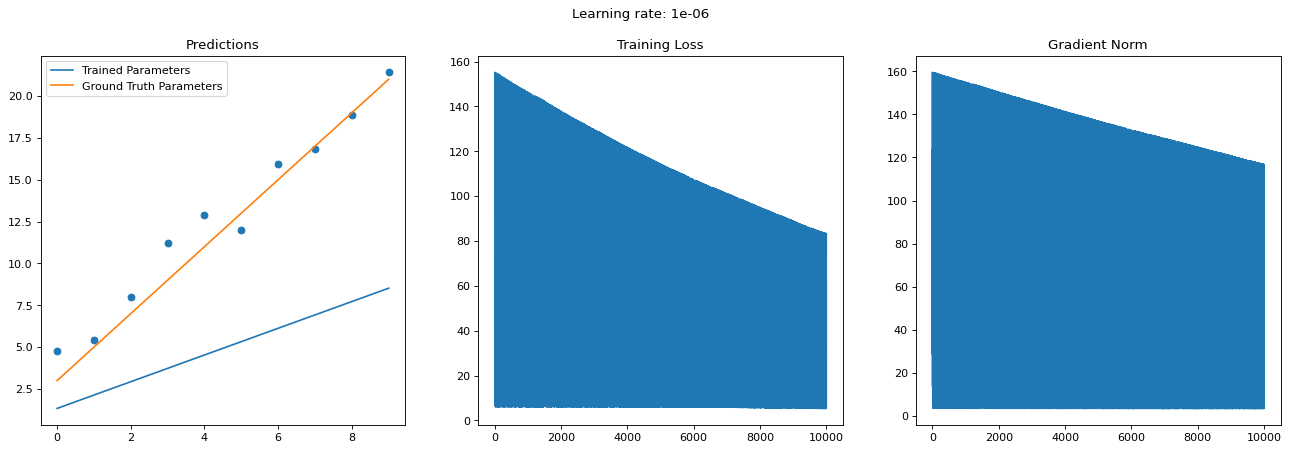

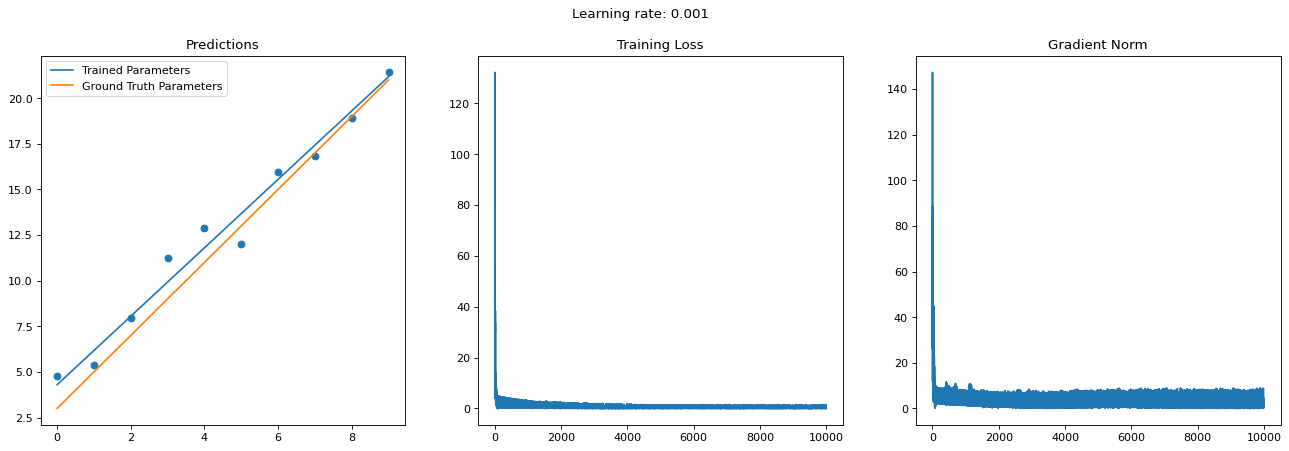

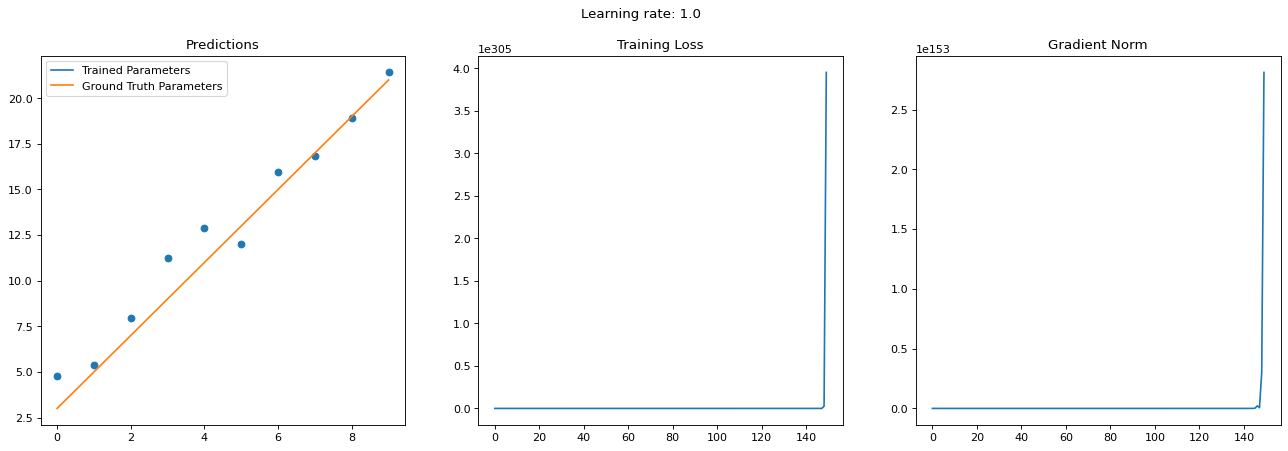

In [14]:
num_iterations = 10000

for learning_rate in [1e-6, 1e-3, 1.0]:
    w, step_infos = train(seed, train_X, train_y, learning_rate, num_iterations, sgd)

    fig = visualize_2d(train_X, train_y, w, true_w, step_infos)
    fig.suptitle("Learning rate: {}".format(learning_rate))

## Impact of Optimizer
How does SGD compare with having momentum?
What if we set learning rate to be too large again?

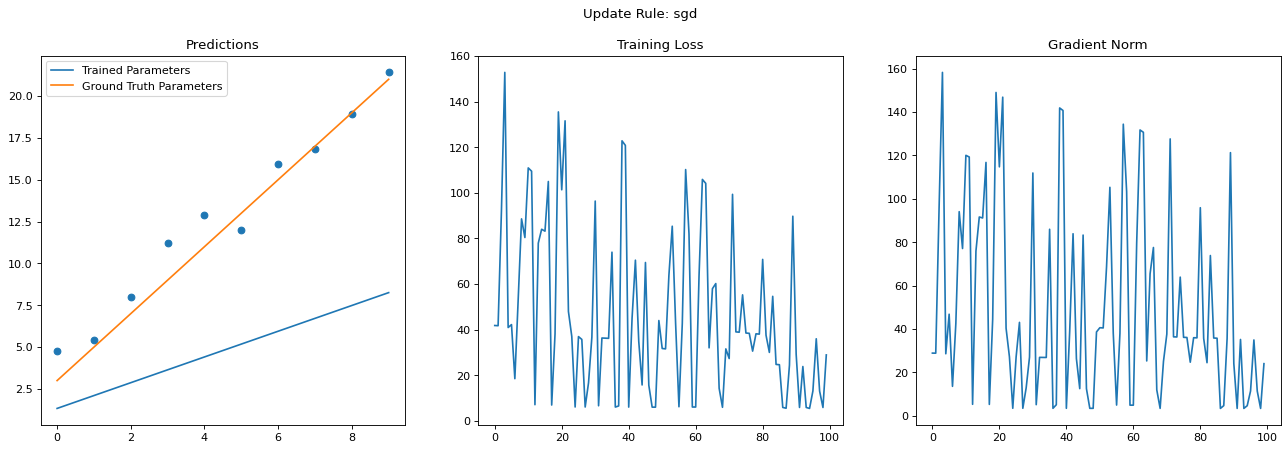

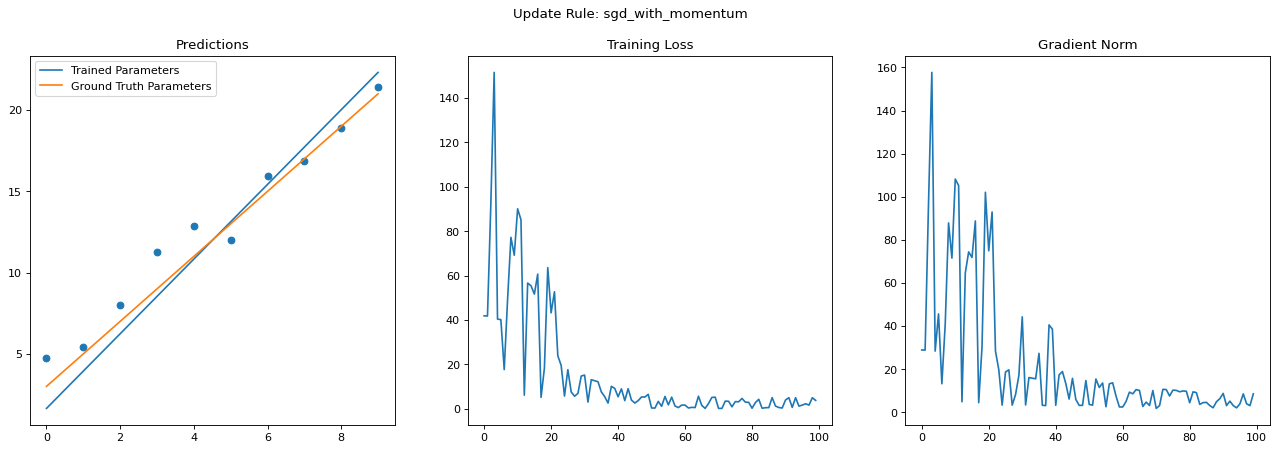

In [15]:
num_iterations = 100
learning_rate = 1e-4

for update_rule in [sgd, sgd_with_momentum]:
    w, step_infos = train(seed, train_X, train_y, learning_rate, num_iterations, update_rule)

    fig = visualize_2d(train_X, train_y, w, true_w, step_infos)
    fig.suptitle("Update Rule: {}".format(update_rule.__name__))